# DA Event Definition Comparison

This notebook compares dopamine alignment for three candidate event definitions:

- behavior onset
- syllable onset
- syllable transition onset

It also tests whether transition identity adds explanatory power beyond behavior and social context, then follows up with grouped-transition and 3-state motif analyses if raw single transitions look weak.


In [45]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

sns.set_context("talk")
sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)


def candidate_base_dirs():
    cwd = Path.cwd().resolve()
    seen = set()
    candidates = []
    for candidate in [cwd, *cwd.parents]:
        for option in [candidate, candidate / "Keypoint_moseq_analysis"]:
            option = option.resolve()
            if option not in seen and option.exists():
                seen.add(option)
                candidates.append(option)
    return candidates


def find_first_existing(relative_path_options):
    for base_dir in candidate_base_dirs():
        for rel_path in relative_path_options:
            candidate = (base_dir / rel_path).resolve()
            if candidate.exists():
                return candidate
    raise FileNotFoundError(f"Could not find any of: {relative_path_options}")


DA_PATH = find_first_existing([
    Path("Pose_Tracking") / "home_cage_pose_DA_all.csv",
    Path("..") / "Pose_Tracking" / "home_cage_pose_DA_all.csv",
])

RUNS_PATH = find_first_existing([
    Path("Pose_Tracking") / "syllable_transition_da_alignment_outputs" / "subject_syllable_runs.csv",
    Path("Keypoint_moseq_analysis") / "Pose_Tracking" / "syllable_transition_da_alignment_outputs" / "subject_syllable_runs.csv",
])

TRANSITIONS_PATH = find_first_existing([
    Path("Pose_Tracking") / "syllable_transition_da_alignment_outputs" / "subject_syllable_transitions.csv",
    Path("Keypoint_moseq_analysis") / "Pose_Tracking" / "syllable_transition_da_alignment_outputs" / "subject_syllable_transitions.csv",
])

OUTPUT_DIR = RUNS_PATH.parent
ANALYSIS_DIR = OUTPUT_DIR.parents[1]
NOTEBOOK_OUTPUT_DIR = OUTPUT_DIR / "event_definition_comparison_outputs"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ROOT = ANALYSIS_DIR.parent if ANALYSIS_DIR.name == "Keypoint_moseq_analysis" else ANALYSIS_DIR

PRE_S = 3.0
POST_S = 3.0
ALIGN_TOL_S = 0.15
TOP_N_LABELS = 6
MIN_LABEL_SUPPORT = 12
COMMON_SYLLABLE_TOP_N = 8
WEAK_DELTA_R2_THRESHOLD = 0.02
KNOWN_BOUTS = ["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"]
REGION_ORDER = ["NAc", "mPFC"]

print(f"DA_PATH: {DA_PATH}")
print(f"RUNS_PATH: {RUNS_PATH}")
print(f"TRANSITIONS_PATH: {TRANSITIONS_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")


DA_PATH: C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\home_cage_pose_DA_all.csv
RUNS_PATH: C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\Pose_Tracking\syllable_transition_da_alignment_outputs\subject_syllable_runs.csv
TRANSITIONS_PATH: C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\Pose_Tracking\syllable_transition_da_alignment_outputs\subject_syllable_transitions.csv
OUTPUT_DIR: C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\Pose_Tracking\syllable_transition_da_alignment_outputs


In [46]:
def normalize_flag(series):
    out = series.fillna("No").astype(str).str.strip().str.lower()
    return out.isin(["yes", "true", "1"])


def clean_behavior(series):
    out = series.fillna("").astype(str).str.strip()
    return out.replace("", "none")


def classify_social_role(agent_in_subject, subject_in_agent):
    agent_bool = normalize_flag(agent_in_subject)
    subject_bool = normalize_flag(subject_in_agent)
    role = np.full(len(agent_bool), "none", dtype=object)
    role[np.asarray(agent_bool) & np.asarray(subject_bool)] = "both"
    role[np.asarray(agent_bool) & ~np.asarray(subject_bool)] = "agent_in_subject"
    role[~np.asarray(agent_bool) & np.asarray(subject_bool)] = "subject_in_agent"
    return pd.Series(role)


def load_da_table(path):
    da = pd.read_csv(path)
    da["time_s"] = pd.to_numeric(da["time_s"], errors="coerce")
    da["zscore_DA"] = pd.to_numeric(da["zscore_DA"], errors="coerce")
    da = da.dropna(subset=["time_s", "zscore_DA"]).copy()
    da["subject_name"] = da["mouse_identity"].astype(str)
    da["bout_phase"] = da["intruder_identity"].astype(str)
    da["behavior_active_clean"] = clean_behavior(da.get("behavior_active", pd.Series(index=da.index, dtype=object)))
    da["agent_in_subject_bool"] = normalize_flag(da.get("agent_in_subject", pd.Series(index=da.index, dtype=object)))
    da["subject_in_agent_bool"] = normalize_flag(da.get("subject_in_agent", pd.Series(index=da.index, dtype=object)))
    da["social_proximity"] = da["agent_in_subject_bool"] | da["subject_in_agent_bool"]
    da["social_role"] = classify_social_role(da.get("agent_in_subject"), da.get("subject_in_agent"))
    da = da.sort_values(["subject_name", "brain_region", "time_s"]).reset_index(drop=True)
    return da


def load_runs_table(path):
    runs = pd.read_csv(path)
    for col in ["start_time_s", "end_time_s", "duration_s", "fps"]:
        runs[col] = pd.to_numeric(runs[col], errors="coerce")
    runs["syllable"] = pd.to_numeric(runs["syllable"], errors="coerce").astype("Int64")
    runs = runs.dropna(subset=["start_time_s", "syllable"]).copy()
    runs["syllable"] = runs["syllable"].astype(int)
    runs = runs.sort_values(["recording_name", "start_time_s"]).reset_index(drop=True)
    return runs


def load_transition_table(path):
    tr = pd.read_csv(path)
    for col in ["entry_time_s", "from_syllable", "to_syllable"]:
        tr[col] = pd.to_numeric(tr[col], errors="coerce")
    tr = tr.dropna(subset=["entry_time_s", "from_syllable", "to_syllable"]).copy()
    tr["from_syllable"] = tr["from_syllable"].astype(int)
    tr["to_syllable"] = tr["to_syllable"].astype(int)
    tr["changed"] = normalize_flag(tr.get("changed", pd.Series(index=tr.index, dtype=object)))
    tr = tr.sort_values(["recording_name", "entry_time_s"]).reset_index(drop=True)
    return tr


da_df = load_da_table(DA_PATH)
runs_df = load_runs_table(RUNS_PATH)
transitions_df = load_transition_table(TRANSITIONS_PATH)

display(da_df[["subject_name", "brain_region", "bout_phase", "time_s", "zscore_DA", "behavior_active_clean", "social_role"]].head())
display(runs_df.head())
display(transitions_df.head())


,subject_name,brain_region,bout_phase,time_s,zscore_DA,behavior_active_clean,social_role
0,n5,NAc,Short_Term-1,184.1,-0.518274,none,none
1,n5,NAc,Short_Term-1,184.2,-0.327248,none,none
2,n5,NAc,Short_Term-1,184.3,-0.295615,none,none
3,n5,NAc,Short_Term-1,184.4,-0.349986,none,none
4,n5,NAc,Short_Term-1,184.5,-0.483705,none,none


,recording_name,subject_name,brain_region,bout_phase,syllable,start_time_s,end_time_s,n_frames,fps,duration_s
0,n5_subject,n5,NAc,NaN,1,0.1,0.9,9,10.0,0.9
1,n5_subject,n5,NAc,NaN,0,1.0,1.0,1,10.0,0.1
2,n5_subject,n5,NAc,NaN,2,1.1,1.4,4,10.0,0.4
3,n5_subject,n5,NAc,NaN,6,1.5,1.7,3,10.0,0.3
4,n5_subject,n5,NAc,NaN,5,1.8,4.7,30,10.0,3.0


,event_id,recording_name,subject_name,brain_region,entry_time_s,entry_frame_index,from_syllable,to_syllable,bout_phase,bout_start_s,bout_end_s,behavior_active,agent_in_subject,subject_in_agent,social_proximity,social_role,changed,transition_label
0,7,n5_subject,n5,NAc,210.3,2103,13,5,Short_Term-1,184.1,484.1,Investigation,No,Yes,True,subject_in_agent,True,13->5
1,8,n5_subject,n5,NAc,210.6,2106,5,9,Short_Term-1,184.1,484.1,Investigation,No,Yes,True,subject_in_agent,True,5->9
2,14,n5_subject,n5,NAc,220.7,2207,38,31,Short_Term-1,184.1,484.1,Investigation,No,Yes,True,subject_in_agent,True,38->31
3,15,n5_subject,n5,NAc,220.8,2208,31,19,Short_Term-1,184.1,484.1,Investigation,No,Yes,True,subject_in_agent,True,31->19
4,16,n5_subject,n5,NAc,220.9,2209,19,31,Short_Term-1,184.1,484.1,Investigation,No,Yes,True,subject_in_agent,True,19->31


In [47]:
def merge_event_context(events, da_df, tolerance_s=ALIGN_TOL_S):
    if events.empty:
        return events.copy()

    left = events.sort_values(["subject_name", "brain_region", "event_time_s"]).copy()
    right = da_df[
        [
            "subject_name",
            "brain_region",
            "time_s",
            "bout_phase",
            "behavior_active_clean",
            "agent_in_subject",
            "subject_in_agent",
            "social_proximity",
            "social_role",
            "zscore_DA",
        ]
    ].sort_values(["subject_name", "brain_region", "time_s"]).copy()

    merged_parts = []
    for (subject_name, brain_region), left_part in left.groupby(["subject_name", "brain_region"], sort=False):
        right_part = right[
            (right["subject_name"] == subject_name)
            & (right["brain_region"] == brain_region)
        ].copy()
        if right_part.empty:
            part = left_part.copy()
            part["time_s"] = np.nan
            part["bout_phase_context"] = pd.NA
            part["behavior_active_at_event"] = pd.NA
            part["agent_in_subject_at_event"] = pd.NA
            part["subject_in_agent_at_event"] = pd.NA
            part["social_proximity_at_event"] = pd.NA
            part["social_role_at_event"] = pd.NA
            part["zscore_at_event"] = np.nan
            merged_parts.append(part)
            continue

        part = pd.merge_asof(
            left_part.sort_values("event_time_s"),
            right_part.sort_values("time_s"),
            left_on="event_time_s",
            right_on="time_s",
            direction="nearest",
            tolerance=tolerance_s,
            suffixes=("", "_at_event"),
        )
        merged_parts.append(part)

    merged = pd.concat(merged_parts, ignore_index=True)

    merged = merged.rename(
        columns={
            "bout_phase": "bout_phase_context",
            "behavior_active_clean": "behavior_active_at_event",
            "agent_in_subject": "agent_in_subject_at_event",
            "subject_in_agent": "subject_in_agent_at_event",
            "social_proximity": "social_proximity_at_event",
            "social_role": "social_role_at_event",
            "zscore_DA": "zscore_at_event",
        }
    )

    if "bout_phase" in merged.columns:
        merged["bout_phase"] = merged["bout_phase"].replace("", np.nan).fillna(merged["bout_phase_context"])
    else:
        merged["bout_phase"] = merged["bout_phase_context"]

    if "behavior_active" in merged.columns:
        merged["behavior_active"] = clean_behavior(merged["behavior_active"])
    merged["behavior_active_at_event"] = clean_behavior(merged["behavior_active_at_event"])
    return merged


def align_events_to_da(events, da_df, pre_s=PRE_S, post_s=POST_S):
    if events.empty:
        return pd.DataFrame(), pd.DataFrame()

    dt = da_df.groupby(["subject_name", "brain_region"], sort=False)["time_s"].diff().median()
    grid_step = float(dt) if pd.notna(dt) and dt > 0 else 0.1
    rel_grid = np.round(np.arange(-pre_s, post_s + (grid_step / 2.0), grid_step), 4)

    event_rows = []
    long_rows = []

    grouped_events = events.sort_values(["subject_name", "brain_region", "event_time_s"]).groupby(
        ["subject_name", "brain_region"],
        sort=False,
    )

    for (subject_name, brain_region), event_part in grouped_events:
        da_part = da_df[(da_df["subject_name"] == subject_name) & (da_df["brain_region"] == brain_region)].copy()
        if da_part.empty:
            continue

        time_values = da_part["time_s"].to_numpy(dtype=float)
        da_values = da_part["zscore_DA"].to_numpy(dtype=float)

        for idx, event in event_part.reset_index(drop=True).iterrows():
            event_time = float(event["event_time_s"])
            start = event_time - pre_s
            stop = event_time + post_s
            seg = da_part[(da_part["time_s"] >= start) & (da_part["time_s"] <= stop)].copy()
            if len(seg) < 5:
                continue

            rel_time = seg["time_s"].to_numpy(dtype=float) - event_time
            if rel_time.min() > -pre_s * 0.8 or rel_time.max() < post_s * 0.8:
                continue

            trace = np.interp(rel_grid, rel_time, seg["zscore_DA"].to_numpy(dtype=float))
            pre_mask = rel_grid < 0
            post_mask = rel_grid >= 0
            center_idx = int(np.argmin(np.abs(time_values - event_time)))

            peak_post_idx = np.argmax(trace[post_mask])
            peak_pre = float(np.max(trace[pre_mask])) if pre_mask.any() else np.nan
            peak_post = float(np.max(trace[post_mask])) if post_mask.any() else np.nan
            peak_latency_s = float(rel_grid[post_mask][peak_post_idx]) if post_mask.any() else np.nan

            event_key = f"{event['event_family']}_{subject_name}_{brain_region}_{idx}_{event_time:.3f}"
            event_record = event.to_dict()
            event_record.update(
                {
                    "event_key": event_key,
                    "zscore_at_event": float(da_values[center_idx]),
                    "mean_pre": float(np.mean(trace[pre_mask])) if pre_mask.any() else np.nan,
                    "mean_post": float(np.mean(trace[post_mask])) if post_mask.any() else np.nan,
                    "peak_pre": peak_pre,
                    "peak_post": peak_post,
                    "peak_latency_s": peak_latency_s,
                    "auc_pre": float(np.trapz(trace[pre_mask], rel_grid[pre_mask])) if pre_mask.sum() > 1 else np.nan,
                    "auc_post": float(np.trapz(trace[post_mask], rel_grid[post_mask])) if post_mask.sum() > 1 else np.nan,
                    "trace": trace.tolist(),
                    "rel_time_grid": rel_grid.tolist(),
                }
            )
            event_rows.append(event_record)

            for rel_t, z_val in zip(rel_grid, trace):
                long_rows.append(
                    {
                        "event_key": event_key,
                        "subject_name": subject_name,
                        "brain_region": brain_region,
                        "event_family": event["event_family"],
                        "event_label": event["event_label"],
                        "rel_time_s": float(rel_t),
                        "zscore_DA": float(z_val),
                    }
                )

    aligned_events = pd.DataFrame(event_rows)
    aligned_long = pd.DataFrame(long_rows)
    if not aligned_events.empty:
        aligned_events["delta_mean"] = aligned_events["mean_post"] - aligned_events["mean_pre"]
        aligned_events["delta_auc"] = aligned_events["auc_post"] - aligned_events["auc_pre"]
    return aligned_events, aligned_long


def build_behavior_onsets(da_df):
    pieces = []
    for (subject_name, brain_region), part in da_df.groupby(["subject_name", "brain_region"], sort=False):
        part = part.sort_values("time_s").copy()
        curr = part["behavior_active_clean"]
        prev = curr.shift(1, fill_value="none")
        mask = (curr != "none") & (curr != prev)
        keep = part.loc[mask, ["subject_name", "brain_region", "time_s", "bout_phase", "behavior_active_clean"]].copy()
        keep = keep.rename(columns={"time_s": "event_time_s", "behavior_active_clean": "behavior_label"})
        keep["event_family"] = "behavior_onset"
        keep["event_label"] = keep["behavior_label"]
        pieces.append(keep)
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()


def build_syllable_onsets(runs_df, da_df):
    events = runs_df[["recording_name", "subject_name", "brain_region", "start_time_s", "end_time_s", "duration_s", "syllable", "bout_phase"]].copy()
    events = events.rename(columns={"start_time_s": "event_time_s"})
    events["syllable_label"] = events["syllable"].astype(str)
    events["event_family"] = "syllable_onset"
    events["event_label"] = events["syllable_label"]
    events = merge_event_context(events, da_df)
    events = events[events["bout_phase"].isin(KNOWN_BOUTS)].reset_index(drop=True)
    return events


def build_transition_onsets(transitions_df, da_df):
    events = transitions_df.copy()
    events = events[events["changed"]].copy()
    events = events.rename(columns={"entry_time_s": "event_time_s"})
    events["event_family"] = "transition_onset"
    events["event_label"] = events["transition_label"].astype(str)
    events = merge_event_context(events, da_df)
    events = events[events["bout_phase"].isin(KNOWN_BOUTS)].reset_index(drop=True)
    return events


behavior_events = build_behavior_onsets(da_df)
syllable_events = build_syllable_onsets(runs_df, da_df)
transition_events = build_transition_onsets(transitions_df, da_df)

behavior_aligned, behavior_long = align_events_to_da(behavior_events, da_df)
syllable_aligned, syllable_long = align_events_to_da(syllable_events, da_df)
transition_aligned, transition_long = align_events_to_da(transition_events, da_df)

all_aligned = pd.concat([behavior_aligned, syllable_aligned, transition_aligned], ignore_index=True)
all_long = pd.concat([behavior_long, syllable_long, transition_long], ignore_index=True)

display(all_aligned.groupby(["event_family", "brain_region"]).size().rename("n_events").reset_index())


,event_family,brain_region,n_events
0,behavior_onset,NAc,68
1,behavior_onset,mPFC,89
2,syllable_onset,NAc,6520
3,syllable_onset,mPFC,10573
4,transition_onset,NAc,1392
5,transition_onset,mPFC,2892


,event_family,brain_region,n_events,n_subjects,n_labels,mean_delta_mean,mean_peak_post,mean_delta_auc
0,behavior_onset,NAc,68,11,3,0.935970,3.901870,2.923718
2,syllable_onset,NAc,6520,11,53,-0.021107,1.295904,-0.057895
4,transition_onset,NAc,1392,11,310,-0.011042,1.575809,-0.010712
1,behavior_onset,mPFC,89,14,5,0.156684,1.422022,0.517210
3,syllable_onset,mPFC,10573,14,48,-0.004953,0.672154,-0.017984
5,transition_onset,mPFC,2892,14,374,-0.002517,0.839260,0.005290


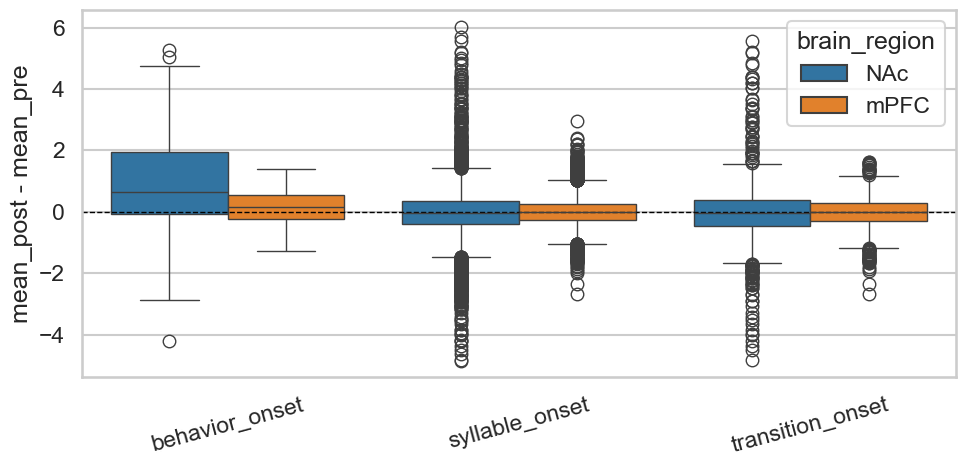

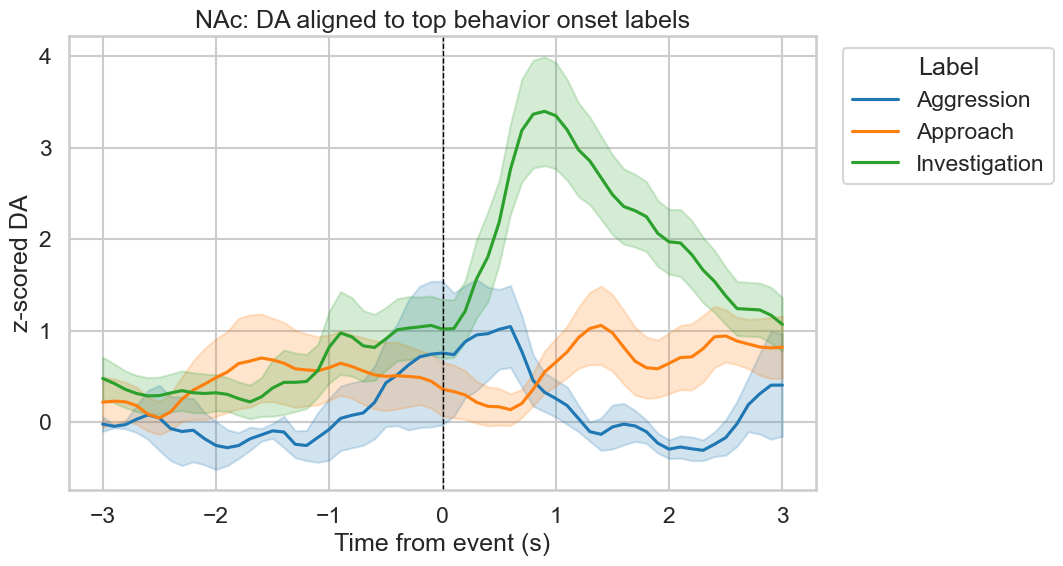

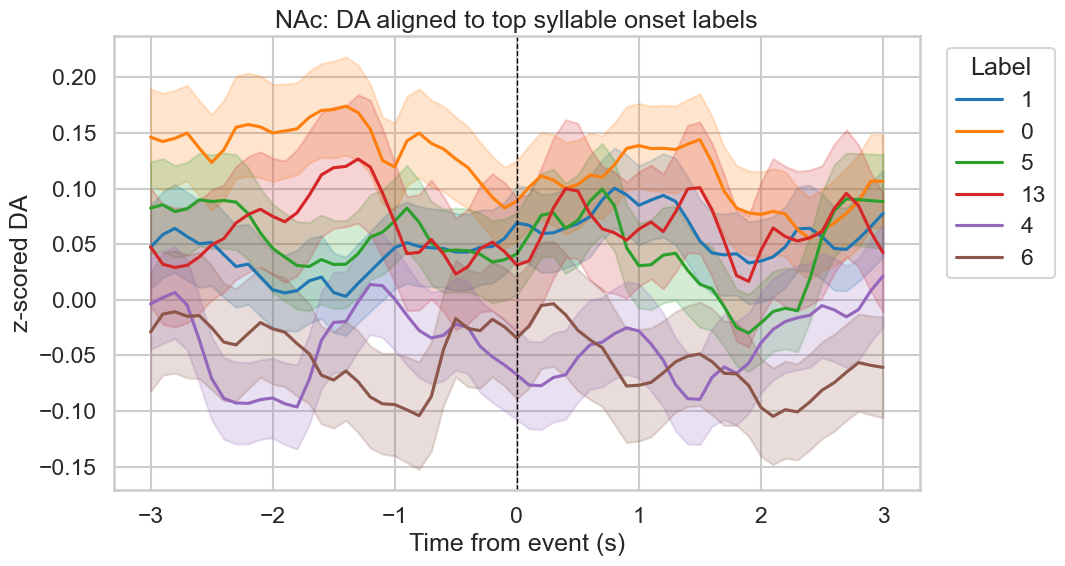

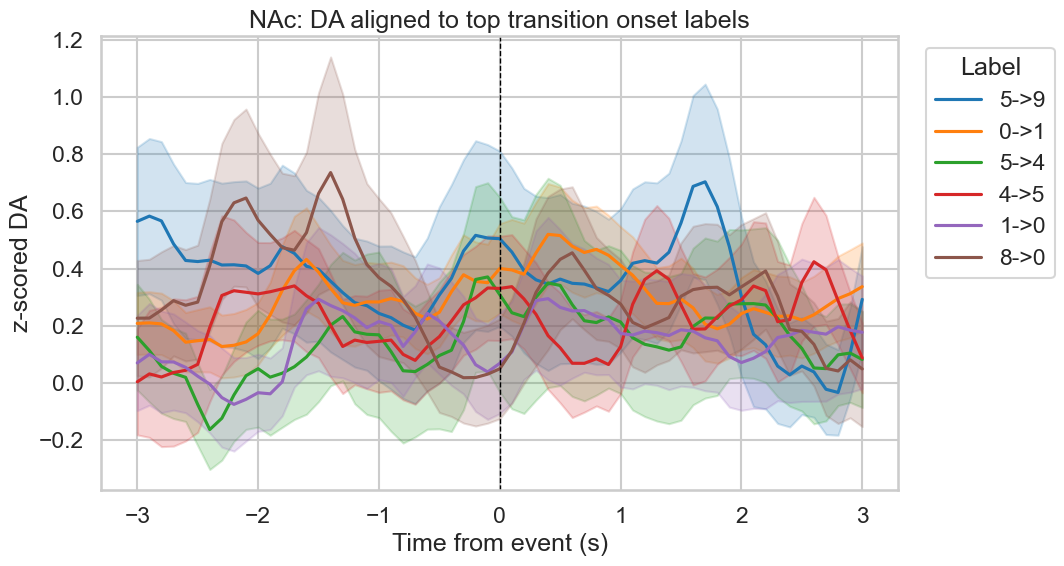

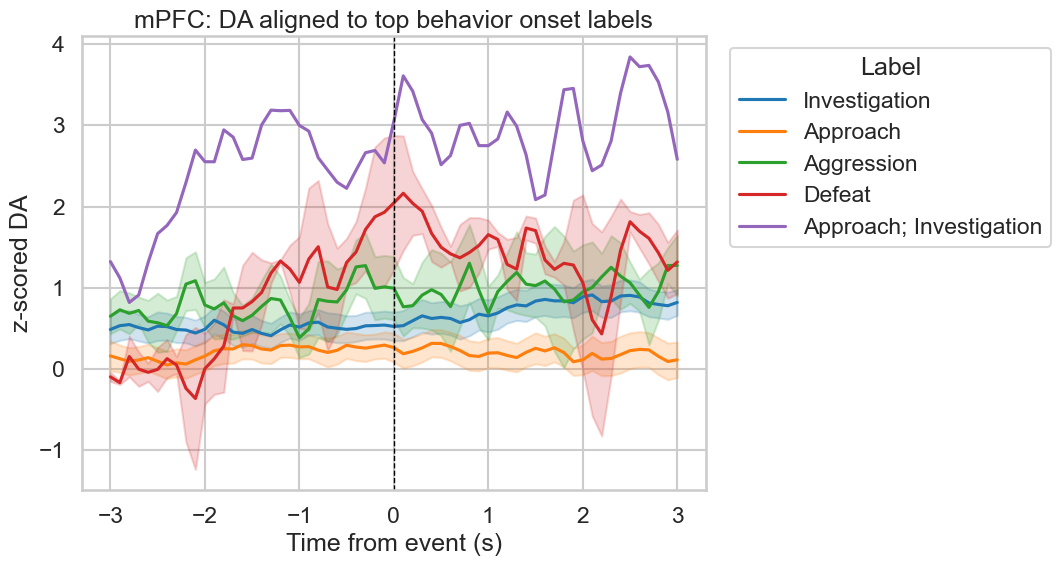

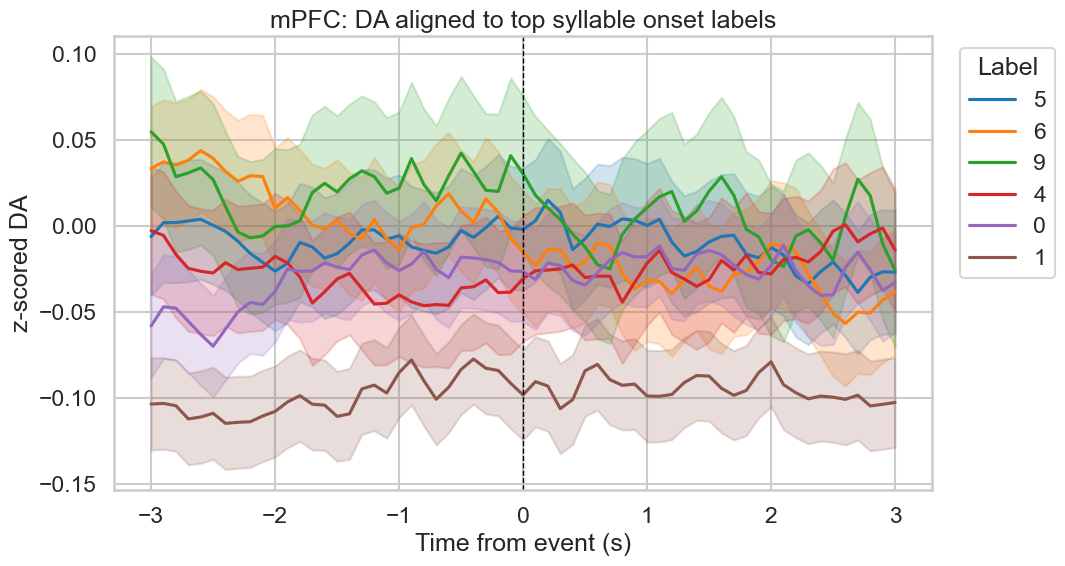

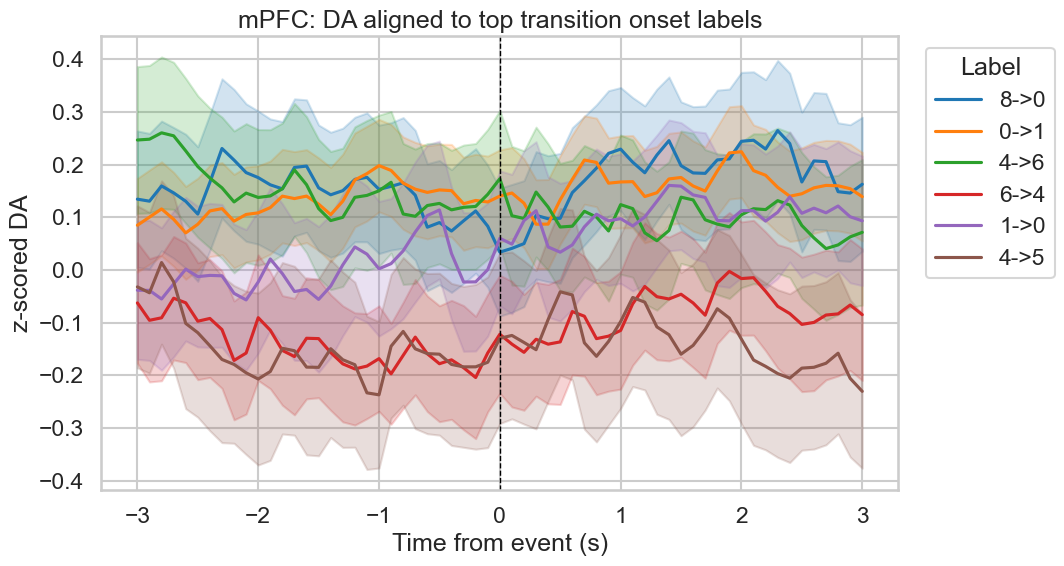

In [48]:
def summarize_event_families(aligned_df):
    summary = (
        aligned_df.groupby(["event_family", "brain_region"], as_index=False)
        .agg(
            n_events=("event_key", "size"),
            n_subjects=("subject_name", "nunique"),
            n_labels=("event_label", "nunique"),
            mean_delta_mean=("delta_mean", "mean"),
            mean_peak_post=("peak_post", "mean"),
            mean_delta_auc=("delta_auc", "mean"),
        )
        .sort_values(["brain_region", "event_family"])
    )
    return summary


def plot_top_label_peths(long_df, aligned_df, event_family, region, top_n=TOP_N_LABELS):
    subset_events = aligned_df[(aligned_df["event_family"] == event_family) & (aligned_df["brain_region"] == region)].copy()
    if subset_events.empty:
        print(f"No events for {event_family} in {region}.")
        return

    top_labels = subset_events["event_label"].value_counts().head(top_n).index.tolist()
    plot_df = long_df[
        (long_df["event_family"] == event_family)
        & (long_df["brain_region"] == region)
        & (long_df["event_label"].isin(top_labels))
    ].copy()
    if plot_df.empty:
        print(f"No long-form trace rows for {event_family} in {region}.")
        return

    plt.figure(figsize=(11, 6))
    sns.lineplot(data=plot_df, x="rel_time_s", y="zscore_DA", hue="event_label", estimator="mean", errorbar="se")
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title(f"{region}: DA aligned to top {event_family.replace('_', ' ')} labels")
    plt.xlabel("Time from event (s)")
    plt.ylabel("z-scored DA")
    plt.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


family_summary = summarize_event_families(all_aligned)
display(family_summary)

plt.figure(figsize=(10, 5))
sns.boxplot(data=all_aligned, x="event_family", y="delta_mean", hue="brain_region", order=["behavior_onset", "syllable_onset", "transition_onset"])
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xticks(rotation=15)
plt.ylabel("mean_post - mean_pre")
plt.xlabel("")
plt.tight_layout()
plt.show()

for region in REGION_ORDER:
    for family in ["behavior_onset", "syllable_onset", "transition_onset"]:
        plot_top_label_peths(all_long, all_aligned, family, region)


## Does transition identity add information beyond behavior and social context?

The baseline model includes `brain_region`, `bout_phase`, `behavior_active_at_event`, and `social_role_at_event`. The second model adds `transition_label`.


,target,model_name,mean_r2,mean_mae
0,delta_mean,baseline,-0.020856,0.461463
1,delta_mean,baseline_plus_transition,-0.050190,0.471569
2,peak_post,baseline,0.067621,1.012461
3,peak_post,baseline_plus_transition,0.029214,1.034635


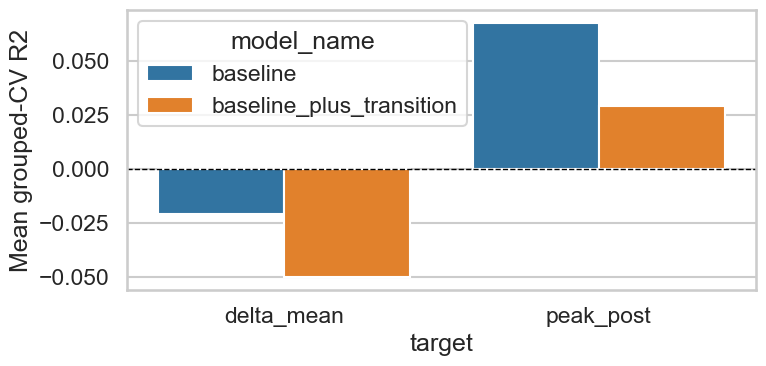

Delta R2 for peak_post with transition identity: -0.038
Delta R2 for delta_mean with transition identity: -0.029


In [49]:
def evaluate_grouped_cv(df, feature_sets, target_col, group_col="subject_name", alpha=1.0):
    work = df.dropna(subset=[target_col, group_col]).copy()
    n_groups = work[group_col].nunique()
    if work.empty or n_groups < 2:
        return pd.DataFrame()

    n_splits = min(5, n_groups)
    splitter = GroupKFold(n_splits=n_splits)
    groups = work[group_col]
    rows = []

    for model_name, feature_cols in feature_sets.items():
        X = work[feature_cols].fillna("none").astype(str)
        y = work[target_col].to_numpy(dtype=float)
        pipe = Pipeline(
            [
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ("ridge", Ridge(alpha=alpha)),
            ]
        )

        for fold_idx, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups=groups), start=1):
            pipe.fit(X.iloc[train_idx], y[train_idx])
            pred = pipe.predict(X.iloc[test_idx])
            rows.append(
                {
                    "model_name": model_name,
                    "target": target_col,
                    "fold": fold_idx,
                    "r2": float(r2_score(y[test_idx], pred)),
                    "mae": float(mean_absolute_error(y[test_idx], pred)),
                    "n_train": int(len(train_idx)),
                    "n_test": int(len(test_idx)),
                }
            )

    return pd.DataFrame(rows)


transition_model_df = transition_aligned.copy()
transition_model_df["behavior_active_at_event"] = clean_behavior(transition_model_df["behavior_active_at_event"])
transition_model_df["social_role_at_event"] = transition_model_df["social_role_at_event"].fillna("none").astype(str)
transition_model_df["transition_label"] = transition_model_df["transition_label"].astype(str)
transition_model_df = transition_model_df[
    transition_model_df.groupby("transition_label")["transition_label"].transform("size") >= MIN_LABEL_SUPPORT
].copy()

baseline_features = ["brain_region", "bout_phase", "behavior_active_at_event", "social_role_at_event"]
transition_features = baseline_features + ["transition_label"]

transition_cv_peak = evaluate_grouped_cv(
    transition_model_df,
    {"baseline": baseline_features, "baseline_plus_transition": transition_features},
    target_col="peak_post",
)
transition_cv_delta = evaluate_grouped_cv(
    transition_model_df,
    {"baseline": baseline_features, "baseline_plus_transition": transition_features},
    target_col="delta_mean",
)

transition_cv = pd.concat([transition_cv_peak, transition_cv_delta], ignore_index=True)
transition_cv_summary = transition_cv.groupby(["target", "model_name"], as_index=False).agg(mean_r2=("r2", "mean"), mean_mae=("mae", "mean"))
display(transition_cv_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=transition_cv_summary, x="target", y="mean_r2", hue="model_name")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylabel("Mean grouped-CV R2")
plt.tight_layout()
plt.show()

delta_r2_peak = (
    transition_cv_summary.query("target == 'peak_post' and model_name == 'baseline_plus_transition'")["mean_r2"].iloc[0]
    - transition_cv_summary.query("target == 'peak_post' and model_name == 'baseline'")["mean_r2"].iloc[0]
)
delta_r2_delta = (
    transition_cv_summary.query("target == 'delta_mean' and model_name == 'baseline_plus_transition'")["mean_r2"].iloc[0]
    - transition_cv_summary.query("target == 'delta_mean' and model_name == 'baseline'")["mean_r2"].iloc[0]
)
print(f"Delta R2 for peak_post with transition identity: {delta_r2_peak:.3f}")
print(f"Delta R2 for delta_mean with transition identity: {delta_r2_delta:.3f}")


## Coarser grouped transitions

This collapses rare syllables into `other` so the model can test whether coarser state changes explain DA better than raw single-transition identity.


,target,model_name,mean_r2,mean_mae
0,delta_mean,baseline,-0.020856,0.461463
1,delta_mean,baseline_plus_grouped_transition,-0.037364,0.466519
2,peak_post,baseline,0.067621,1.012461
3,peak_post,baseline_plus_grouped_transition,0.050865,1.023811


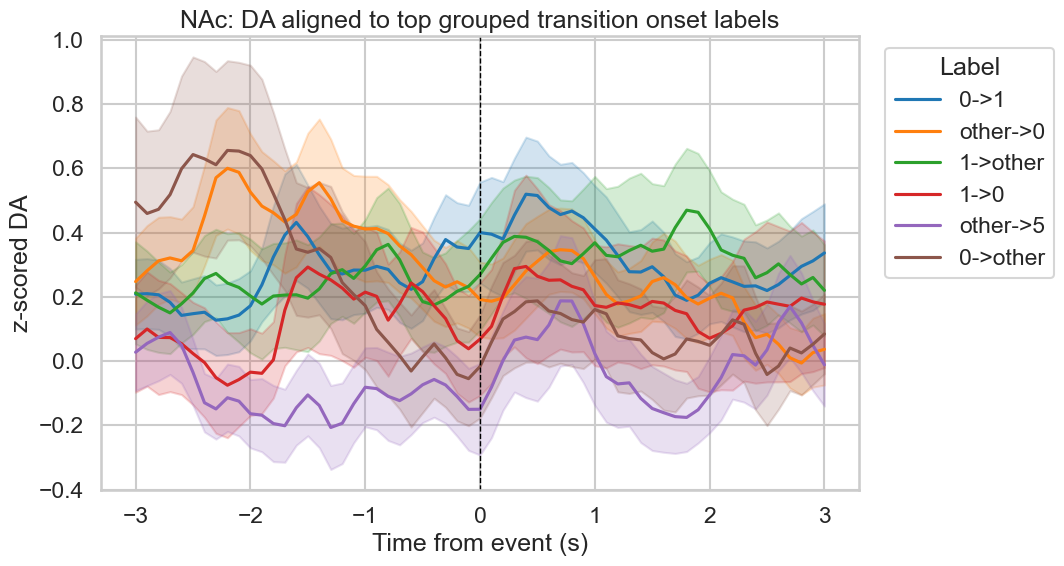

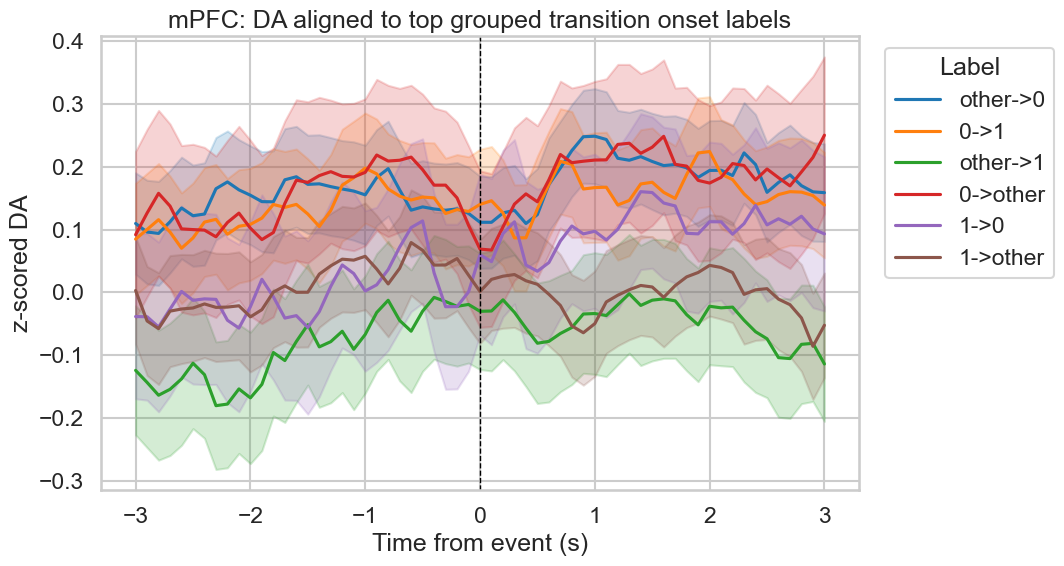

In [50]:
common_syllables = runs_df["syllable"].astype(str).value_counts().head(COMMON_SYLLABLE_TOP_N).index.tolist()


def map_grouped_syllable(value):
    value = str(value)
    return value if value in common_syllables else "other"


transition_grouped_df = transition_model_df.copy()
transition_grouped_df["from_grouped"] = transition_grouped_df["from_syllable"].map(map_grouped_syllable)
transition_grouped_df["to_grouped"] = transition_grouped_df["to_syllable"].map(map_grouped_syllable)
transition_grouped_df["grouped_transition_label"] = transition_grouped_df["from_grouped"] + "->" + transition_grouped_df["to_grouped"]

grouped_cv_peak = evaluate_grouped_cv(
    transition_grouped_df,
    {"baseline": baseline_features, "baseline_plus_grouped_transition": baseline_features + ["grouped_transition_label"]},
    target_col="peak_post",
)
grouped_cv_delta = evaluate_grouped_cv(
    transition_grouped_df,
    {"baseline": baseline_features, "baseline_plus_grouped_transition": baseline_features + ["grouped_transition_label"]},
    target_col="delta_mean",
)

grouped_cv = pd.concat([grouped_cv_peak, grouped_cv_delta], ignore_index=True)
grouped_cv_summary = grouped_cv.groupby(["target", "model_name"], as_index=False).agg(mean_r2=("r2", "mean"), mean_mae=("mae", "mean"))
display(grouped_cv_summary)

grouped_transition_events = transition_grouped_df.copy()
grouped_transition_events["event_label"] = grouped_transition_events["grouped_transition_label"]
grouped_transition_events["event_family"] = "grouped_transition_onset"
grouped_transition_long = transition_long.drop(columns=["event_label", "event_family"], errors="ignore").merge(
    grouped_transition_events[["event_key", "event_label", "event_family"]],
    on="event_key",
    how="inner",
)

for region in REGION_ORDER:
    plot_top_label_peths(grouped_transition_long, grouped_transition_events, "grouped_transition_onset", region)


## Three-state motifs

Motifs are defined at syllable onset as `prev -> current -> next`. If raw transitions are too granular, motifs sometimes recover higher-level action fragments that are more DA-relevant.


,brain_region,n_events
0,NAc,3599
1,mPFC,5678


,target,model_name,mean_r2,mean_mae
0,delta_mean,baseline,-0.004106,0.413347
1,delta_mean,baseline_plus_motif,-0.057923,0.427937
2,peak_post,baseline,0.049906,0.896508
3,peak_post,baseline_plus_motif,0.000954,0.920128


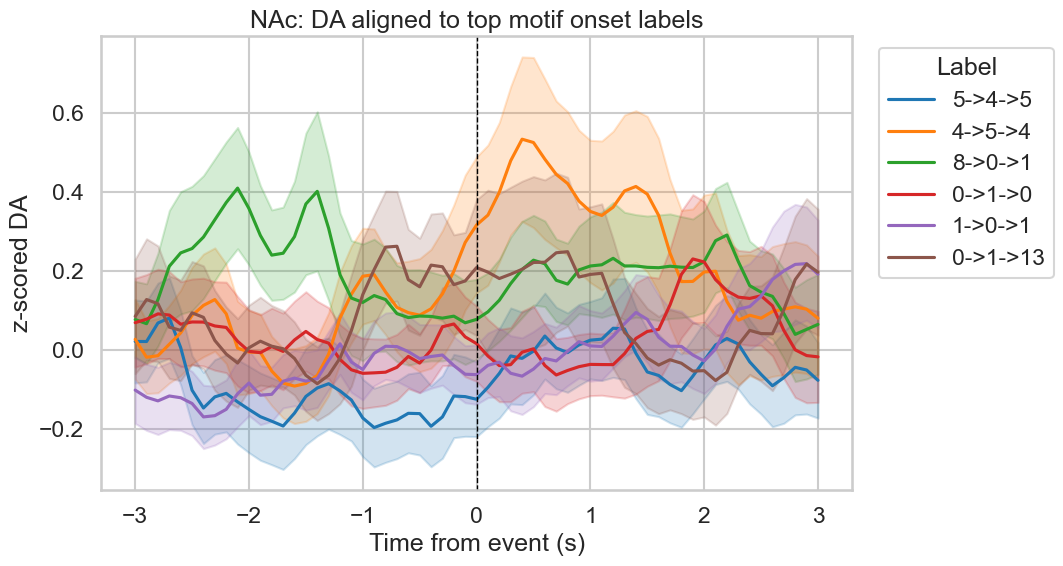

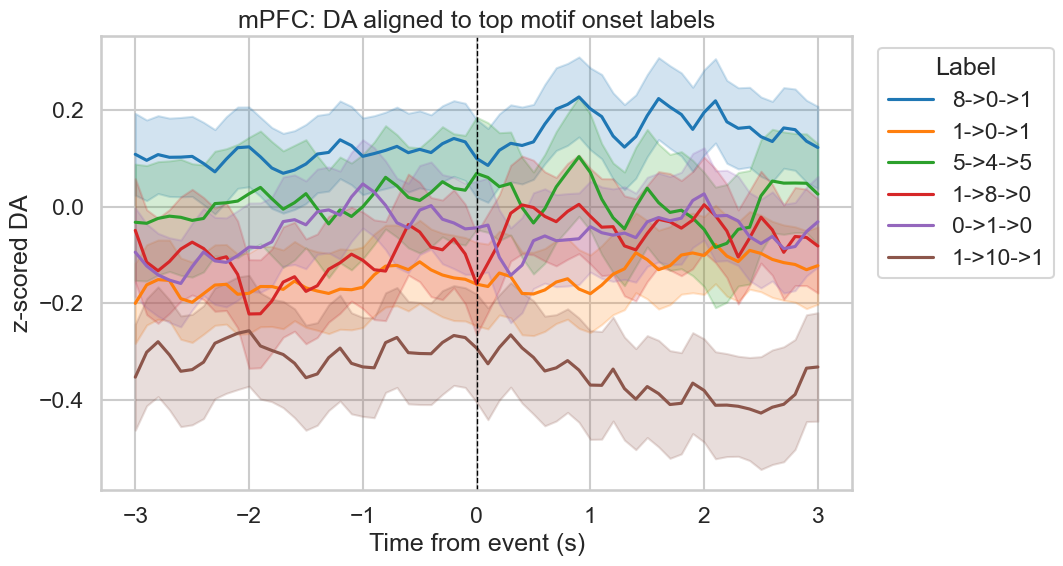

Raw transition identity looks weak by the preset threshold (best delta R2 = -0.029 < 0.020).
Use the grouped-transition and motif summaries above as the primary follow-up analyses.


In [51]:
runs_context = syllable_events.sort_values(["recording_name", "event_time_s"]).copy()
runs_context["prev_syllable"] = runs_context.groupby("recording_name", sort=False)["syllable_label"].shift(1)
runs_context["next_syllable"] = runs_context.groupby("recording_name", sort=False)["syllable_label"].shift(-1)
motif_events = runs_context.dropna(subset=["prev_syllable", "next_syllable"]).copy()
motif_events["motif_label"] = motif_events["prev_syllable"] + "->" + motif_events["syllable_label"] + "->" + motif_events["next_syllable"]
motif_events["event_family"] = "motif_onset"
motif_events["event_label"] = motif_events["motif_label"]
motif_events = motif_events[motif_events.groupby("motif_label")["motif_label"].transform("size") >= MIN_LABEL_SUPPORT].copy()

motif_aligned, motif_long = align_events_to_da(motif_events, da_df)
display(motif_aligned.groupby("brain_region").size().rename("n_events").reset_index())

motif_cv_peak = evaluate_grouped_cv(
    motif_aligned,
    {"baseline": baseline_features, "baseline_plus_motif": baseline_features + ["motif_label"]},
    target_col="peak_post",
)
motif_cv_delta = evaluate_grouped_cv(
    motif_aligned,
    {"baseline": baseline_features, "baseline_plus_motif": baseline_features + ["motif_label"]},
    target_col="delta_mean",
)

motif_cv = pd.concat([motif_cv_peak, motif_cv_delta], ignore_index=True)
motif_cv_summary = motif_cv.groupby(["target", "model_name"], as_index=False).agg(mean_r2=("r2", "mean"), mean_mae=("mae", "mean"))
display(motif_cv_summary)

for region in REGION_ORDER:
    plot_top_label_peths(motif_long, motif_aligned, "motif_onset", region)

single_transition_strength = max(delta_r2_peak, delta_r2_delta)
if single_transition_strength < WEAK_DELTA_R2_THRESHOLD:
    print(
        f"Raw transition identity looks weak by the preset threshold (best delta R2 = {single_transition_strength:.3f} < {WEAK_DELTA_R2_THRESHOLD:.3f})."
    )
    print("Use the grouped-transition and motif summaries above as the primary follow-up analyses.")
else:
    print(
        f"Raw transition identity clears the preset threshold (best delta R2 = {single_transition_strength:.3f})."
    )
    print("Grouped-transition and motif results still help show whether a coarser representation is more interpretable.")


In [52]:
family_summary.to_csv(NOTEBOOK_OUTPUT_DIR / "event_family_summary.csv", index=False)
transition_cv_summary.to_csv(NOTEBOOK_OUTPUT_DIR / "transition_model_summary.csv", index=False)
grouped_cv_summary.to_csv(NOTEBOOK_OUTPUT_DIR / "grouped_transition_model_summary.csv", index=False)
motif_cv_summary.to_csv(NOTEBOOK_OUTPUT_DIR / "motif_model_summary.csv", index=False)
behavior_aligned.to_csv(NOTEBOOK_OUTPUT_DIR / "aligned_behavior_onsets.csv", index=False)
syllable_aligned.to_csv(NOTEBOOK_OUTPUT_DIR / "aligned_syllable_onsets.csv", index=False)
transition_aligned.to_csv(NOTEBOOK_OUTPUT_DIR / "aligned_transition_onsets.csv", index=False)
motif_aligned.to_csv(NOTEBOOK_OUTPUT_DIR / "aligned_motif_onsets.csv", index=False)
print(NOTEBOOK_OUTPUT_DIR)


C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\Pose_Tracking\syllable_transition_da_alignment_outputs\event_definition_comparison_outputs


## Investigation onset split by bout phase

This section isolates behavior onsets labeled `Investigation` and compares DA traces by full `bout_phase`, keeping `Short_Term-1` and `Short_Term-2` separate.


,brain_region,agent_type,n_events,n_subjects,mean_delta_mean,mean_peak_post,mean_delta_auc
0,NAc,Long_Term-1,11,11,1.582975,6.079248,4.936332
1,NAc,Novel-1,11,11,2.374611,6.033290,7.365949
2,NAc,Short_Term-1,8,8,1.681432,6.251774,5.301681
3,NAc,Short_Term-2,8,8,0.126010,1.303458,0.385186
5,mPFC,Novel-1,12,12,0.473151,1.469657,1.453064
6,mPFC,Short_Term-1,12,12,0.102279,2.270422,0.424063
4,mPFC,Long_Term-1,11,11,0.403487,1.696780,1.291725
7,mPFC,Short_Term-2,11,11,-0.009190,0.990435,-0.025906


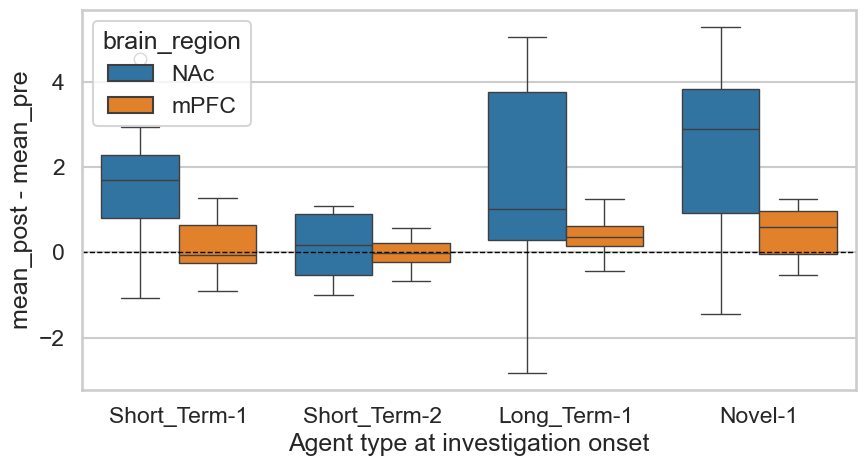

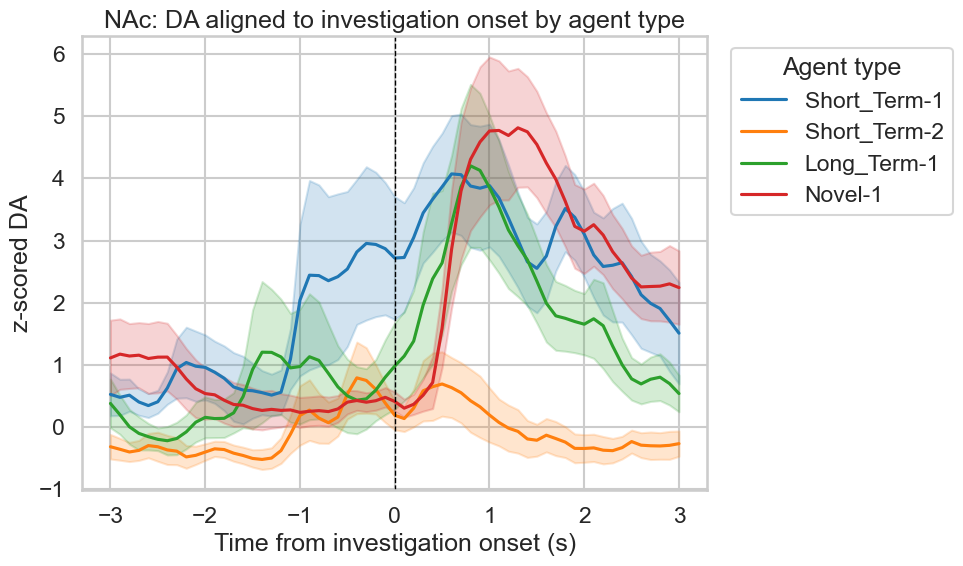

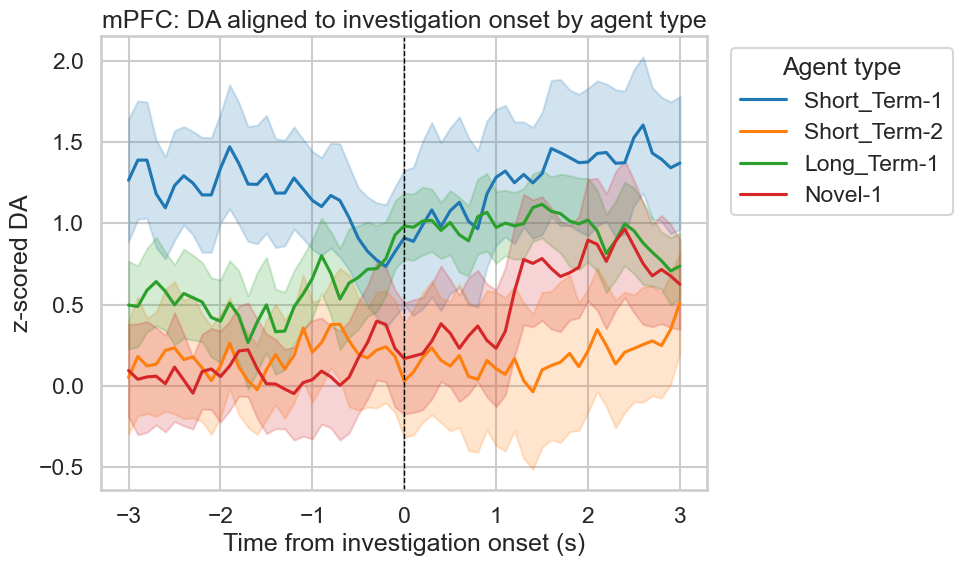

In [53]:
investigation_events = behavior_aligned[
    behavior_aligned["event_label"].astype(str).str.lower().eq("investigation")
].copy()
investigation_events["agent_type"] = investigation_events["bout_phase"].fillna("unknown").astype(str)

investigation_long = behavior_long.merge(
    investigation_events[["event_key", "agent_type"]],
    on="event_key",
    how="inner",
)

investigation_summary = (
    investigation_events.groupby(["brain_region", "agent_type"], as_index=False)
    .agg(
        n_events=("event_key", "size"),
        n_subjects=("subject_name", "nunique"),
        mean_delta_mean=("delta_mean", "mean"),
        mean_peak_post=("peak_post", "mean"),
        mean_delta_auc=("delta_auc", "mean"),
    )
    .sort_values(["brain_region", "n_events"], ascending=[True, False])
)
display(investigation_summary)

agent_order = [
    role for role in ["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1", "unknown"]
    if role in investigation_events["agent_type"].unique()
]

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=investigation_events,
    x="agent_type",
    y="delta_mean",
    hue="brain_region",
    order=agent_order,
)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Agent type at investigation onset")
plt.ylabel("mean_post - mean_pre")
plt.tight_layout()
plt.show()

for region in REGION_ORDER:
    plot_df = investigation_long[investigation_long["brain_region"] == region].copy()
    if plot_df.empty:
        print(f"No investigation onset events for {region}.")
        continue

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=plot_df,
        x="rel_time_s",
        y="zscore_DA",
        hue="agent_type",
        hue_order=agent_order,
        estimator="mean",
        errorbar="se",
    )
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title(f"{region}: DA aligned to investigation onset by agent type")
    plt.xlabel("Time from investigation onset (s)")
    plt.ylabel("z-scored DA")
    plt.legend(title="Agent type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


## How to read the outputs

- If behavior onset shows stronger or cleaner alignment than syllable or transition onset, DA may be better captured at a coarser ethological timescale.
- If adding `transition_label` improves grouped-CV R2 over the baseline context model, transition identity carries extra information beyond behavior and social role.
- If grouped transitions or 3-state motifs outperform raw transitions, the problem is likely that single transitions are too granular rather than that kinematic structure is irrelevant.
